In [1]:
import sys
sys.path.append('../')

import numpy as np
from matplotlib import pyplot as plt
from qutip.qip.operations import rz, cz_gate
import cmath
from tqdm import tqdm
from matplotlib.colors import LogNorm
import datetime
import pytz
import scqubits.settings as settings
settings.OVERLAP_THRESHOLD = 0.3
from joblib import Parallel, delayed
import itertools
import scipy.sparse as ssp
from sympy import symbols
import utils_2Q_gate_zp as ut
ut.set_fig_font() ### Set various sizes in plotting 
import qutip as qt

## Prepare two zero pi 

In [2]:
args_all = ut.get_operator_two_zeropi()

In [7]:
[n_theta1, n_theta2, n_theta1_dress, n_theta2_dress, n_theta1_truc, n_theta2_truc,
eval_tot, order_sort, H0, trunc_states ] = args_all

logi_space = ['00', '02', '20', '22']

## Frequency mismatch

In [8]:
start_list = ['00', '00', '02', '02', '20', '20', '22', '22']
end_list   = ['01', '10', '12', '05', '50', '21', '52', '25']
eff_num = 5  # number of effective digits in np.round()
g_list = []
dw_list = []
state_list = []
mat_list= []
Ec0_vec = np.linspace(1, 2.2, num=1)
for Ec0 in tqdm(Ec0_vec):
    # [g, eval_tot, order_sort] = ut.get_trans_freq(Ec0=Ec0)
    # g_list.append(g)

    for state0, state1 in zip(start_list, end_list):
        dw_list.append(np.abs(ut.transition_frequency(order_sort.index(state0), 
                                                    order_sort.index(state1), 
                                                    eval_tot)))
        state_list.append(state0 + '$\\to$' + state1)

# dw_list = np.reshape(dw_list, (len(Ec0_vec), len(start_list)))

dw_num = len(dw_list)
sort_idxs   = np.array(dw_list).argsort()
state_list  = [state_list[idx] for idx in sort_idxs]
dw_list = np.round( np.sort(dw_list), eff_num )

freq_mismatch_vec = []
for i in range(4):
    freq_mismatch_vec.append(np.abs(dw_list[2*i] - dw_list[2*i+1]))

[print(state_list[i],' : ', dw_list[i]) for i in range(dw_num)];
print(freq_mismatch_vec)

100%|██████████| 1/1 [00:00<00:00, 5817.34it/s]

22$\to$25  :  14.67634
02$\to$05  :  14.69697
20$\to$21  :  15.09333
00$\to$01  :  15.13906
22$\to$52  :  15.92242
20$\to$50  :  15.98409
02$\to$12  :  16.27275
00$\to$10  :  16.30929
[0.020630000000000592, 0.045730000000000715, 0.06166999999999945, 0.03654000000000224]


Text(-0.0, 0.4, 'Frequency (h$\\cdot$GHz)')

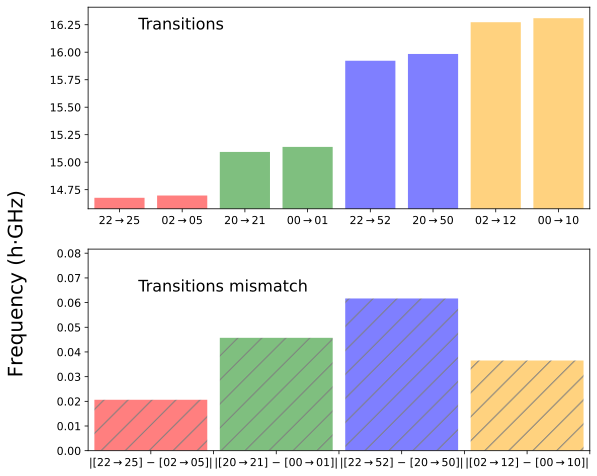

In [9]:

# mismatch_list = ['$|\omega_{02\\to 05}-\omega_{22\\to 25}|$', '',
#                  '$|\omega_{22\\to 52}-\omega_{20\\to 50}|$', '',
#                  '$|\omega_{20\\to 21}-\omega_{00\\to 01}|$', '',
#                  '$|\omega_{02\\to 12}-\omega_{00\\to 10}|$', '']
mismatch_list = [f'|[{state_list[0]}] $-$ [{state_list[1]}]|', '',
                 f'|[{state_list[2]}] $-$ [{state_list[3]}]|', '',
                 f'|[{state_list[4]}] $-$ [{state_list[5]}]|', '',
                 f'|[{state_list[6]}] $-$ [{state_list[7]}]|', '',]
plt.rc(['xtick', 'ytick' ], labelsize=11)    # fontsize of the tick labels
fig, ax = plt.subplots(figsize = (9,8), nrows=2, height_ratios=[1, 1]);
transparency = 0.5
color_vec = ['r', 'g', 'b', 'orange']
for i in range(4):
    ax[0].bar([2*i,2*i+1], dw_list[2*i:2*i+2],  color=color_vec[i], alpha=transparency)
    ax[1].bar(2*i+0.5, freq_mismatch_vec[i], color=color_vec[i], alpha=transparency,  hatch='/',  width=1.8, )

ax[0].set_xticks(range(dw_num), state_list, rotation=0)
# ax[0].legend(loc='upper left')
# ax[0].grid()
ax[0].set_ylim(dw_list[0]-0.1,dw_list[-1]+0.1)
ax[0].set_xlim(-0.5, 7.5)

ax[1].set_xticks(np.arange(8)+0.5, mismatch_list, rotation=0)
ax[1].set_ylim(0,np.max(freq_mismatch_vec)+0.02)
ax[1].set_xlim(-0.5, 7.5)
ax[0].text(0.1, 0.95, 'Transitions', transform=ax[0].transAxes, fontsize=16,  va='top')
ax[1].text(0.1, 0.85, 'Transitions mismatch', transform=ax[1].transAxes, fontsize=16,  va='top')

fig.text(-0.0, 0.4, 'Frequency (h$\cdot$GHz)', va='center', rotation='vertical', size=20)

Text(0, 0.5, 'Frequency')

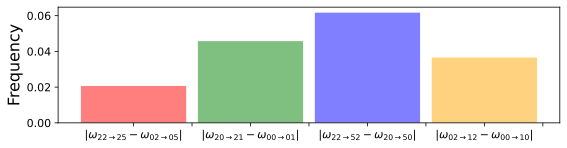

In [31]:
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16
plt.rc('font', size=MEDIUM_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE, labelsize=BIGGER_SIZE)     # fontsize of the axes
plt.rc(['xtick', 'ytick' ], labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title


mismatch_list = ['$|\omega_{22\\to 25}-\omega_{02\\to 05}|$', '',
                 '$|\omega_{20\\to 21}-\omega_{00\\to 01}|$', '',
                 '$|\omega_{22\\to 52}-\omega_{20\\to 50}|$', '',
                 '$|\omega_{02\\to 12}-\omega_{00\\to 10}|$', '']
# mismatch_list = [f'|[{state_list[0]}] $-$ [{state_list[1]}]|', '',
#                  f'|[{state_list[2]}] $-$ [{state_list[3]}]|', '',
#                  f'|[{state_list[4]}] $-$ [{state_list[5]}]|', '',
#                  f'|[{state_list[6]}] $-$ [{state_list[7]}]|', '',]
plt.rc(['xtick', 'ytick' ], labelsize=11)    # fontsize of the tick labels
fig, ax = plt.subplots(figsize = (9,2.1), nrows=1);
transparency = 0.5
color_vec = ['r', 'g', 'b', 'orange']
for i in range(4):
    ax.bar(2*i+0.5, freq_mismatch_vec[i], color=color_vec[i], alpha=transparency,    width=1.8, )
ax.set_xticks(np.arange(8)+0.5, mismatch_list, rotation=0)
# ax.set_ylim(0,np.max(freq_mismatch_vec)+0.02)
# ax.text(0.1, 0.85, 'Transitions mismatch', transform=ax.transAxes, fontsize=16,  va='top')
ax.set_ylabel('Frequency')

ValueError: The number of FixedLocator locations (4), usually from a call to set_ticks, does not match the number of labels (8).

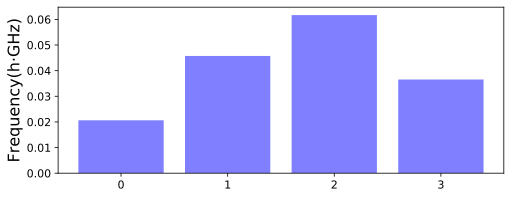

In [10]:
transparency = 0.5
fig, ax = plt.subplots(figsize = (8,3));
plt.bar(range(4), freq_mismatch_vec, label='Frequency mismatch', color='b', alpha=transparency)
plt.ylabel('Frequency(h$\cdot$GHz)')
plt.xticks(range(4), mismatch_list, rotation=0);
plt.legend(loc='best')
plt.grid()
# plt.ylim(dw_list[0]-0.5,dw_list[-1]+0.5)

(14.19007, 16.81768)

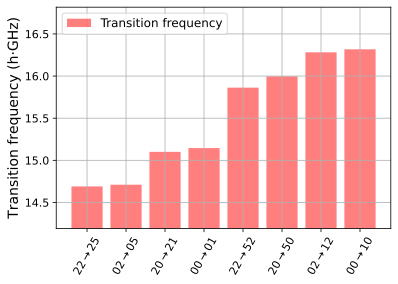

In [ ]:
transparency = 0.5
fig, ax = plt.subplots(figsize = (6,4));
#plt.title('$E_{J2}=0.9E_{J1}$')
plt.xticks(range(dw_num), state_list, rotation=60);
#plt.gca().get_xticklabels()[4].set_color('red')
plt.bar(range(dw_num), dw_list, label='Transition frequency', color='r', alpha=transparency)
plt.ylim(dw_list[0]-0.5, dw_list[-1]+0.5)
plt.ylabel('Transition frequency (h$\cdot$GHz)')
plt.legend(loc='upper left')
plt.grid()
plt.ylim(dw_list[0]-0.5,dw_list[-1]+0.5)

In [ ]:
print(g_list)
print(dw_list)


[0.030999]
[14.69007 14.71051 15.10059 15.14523 15.86275 15.99727 16.28165 16.31768]


In [ ]:
start_list = ['00', '00', '02', '02', '20', '20', '22', '22']
end_list   = ['01', '10', '12', '05', '50', '21', '52', '25']
eff_num = 5  # number of effective digits in np.round()
g_list = []
dw_list = []
state_list = []
mat_list= []
Ec0_vec = np.linspace(0.2, 2.2, num=1)
for Ec0 in tqdm(Ec0_vec):
    [g, eval_tot, order_sort] = ut.get_trans_freq(Ec0=Ec0)
    g_list.append(g)

    for state0, state1 in zip(start_list, end_list):
        dw_list.append(np.abs(ut.transition_frequency(order_sort.index(state0), 
                                                    order_sort.index(state1), 
                                                    eval_tot)))
        state_list.append(state0 + '$\\to$' + state1)

dw_list = np.reshape(dw_list, (len(Ec0_vec), len(start_list)))

dw_num = len(dw_list)
sort_idxs   = np.array(dw_list).argsort()
state_list  = [state_list[idx] for idx in sort_idxs]
dw_list = np.round( np.sort(dw_list), eff_num )

freq_mismatch_vec = []
for i in range(4):
    freq_mismatch_vec.append(np.abs(dw_list[2*i] - dw_list[2*i+1]))

[print(state_list[i],' : ', dw_list[i]) for i in range(dw_num)];
print(freq_mismatch_vec)

100%|██████████| 1/1 [00:08<00:00,  8.30s/it]


TypeError: only integer scalar arrays can be converted to a scalar index